# Notebook 2 (v4) - VelOT ablation studies

**v4 fix.** The VelOT runner now tolerates harmless extra keys in configuration dictionaries. This prevents signature errors when metadata keys such as `name`, `condition`, or plotting labels are passed together with model hyper-parameters.


**Goal.** Quantify how each VelOT hyper-parameter contributes to velocity quality and
runtime on the easy bifurcation. Each ablation is a one-factor-at-a-time deviation from
a published baseline. We then partition the sweep into **four hyper-parameter families**
(*Windowing*, *OT cost*, *Smoothing loss*, *Smoothing network*) so that the figures
respect biological/numerical structure.

The pipeline is called through the working VelOT API:

```python
velot.tl.build_windows(adata, basis="X_pca", ...)
velot.tl.compute_ot_velocity(adata, basis="X_pca", reg=…, lambda_time=…, lambda_knn=…)
velot.tl.smooth_velocity(adata, basis="pca", velocity_key="velot_velocity_raw_pca", ...)
velot.tl.project_to_umap(adata, "velot_velocity_pca", "velot_velocity_umap")
results = velot.metrics.summary(adata, cluster_edges=EDGES, cluster_key="celltype", ...)
```

**Outputs:**
- Pareto plot (speed vs composite quality), annotated.
- Family-grouped panel (4 facets, one per parameter family).
- Heatmap of normalised metrics with hierarchical row clustering.
- Strip + box plots with seed-matched sign-flip permutation tests vs baseline (BH-corrected).
- Velocity-field gallery with streamlines.
- Per-loss convergence curves (regression / smoothness / curl) on a log y-axis.


**v3 update.** This version fixes three visualization/statistical issues reported after
running v2:

1. The smoothing-loss/divergence panel is now zero-aware and the `divergence_0p1`
   ablation is explicitly retained in the example objects, so the divergence component
   is no longer empty or lost on a log axis.
2. Boxplot inference now uses exact paired sign-flip permutation tests matched by seed
   against the baseline, with Benjamini-Hochberg correction per metric. This is safer
   than relying on asymptotic tests with only a few paired repeats. The figure reports
   `ns` and q-values explicitly; the full table also reports paired mean/median deltas
   and the number of paired seeds.
3. The Pareto plot now includes a zoom/inset window around the dense high-quality
   operating region, and the legend is moved outside the plotting area.


In [1]:
from pathlib import Path
import os, sys, warnings, importlib.util, json, time, subprocess, warnings

warnings.filterwarnings("ignore")

REQUIRED_IMPORTS = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "scipy": "scipy",
    "anndata": "anndata",
    "scanpy": "scanpy",
    "ot": "POT",
    "torch": "torch",
}

missing = [
    pip_name
    for module_name, pip_name in REQUIRED_IMPORTS.items()
    if importlib.util.find_spec(module_name) is None
]

if missing:
    raise ImportError(
        "Missing packages:\n"
        + "\n".join(missing)
        + "\n\nInstall them manually with:\n"
        + f"pip install {' '.join(missing)}"
    )

# Import torch BEFORE velot
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Locate VelOT root
PROJECT_ROOT = Path.cwd().resolve()

CANDIDATES = [
    PROJECT_ROOT,
    PROJECT_ROOT.parent,
    PROJECT_ROOT.parent.parent,
]

VELOT_IMPORT_ROOT = None

for c in CANDIDATES:
    if (c / "velot").is_dir():
        VELOT_IMPORT_ROOT = c
        sys.path.insert(0, str(c))
        break

import velot

print(f"VelOT : {getattr(velot, '__version__', 'unknown')}")
print(f"Torch : {torch.__version__}")
print(f"CUDA  : {torch.cuda.is_available()}")
print(f"CWD   : {PROJECT_ROOT}")
print(f"VelOT import root: {VELOT_IMPORT_ROOT}")

VelOT : 0.1.0
Torch : 2.7.1+cu118
CUDA  : True
CWD   : /home/user/Documents/velot/notebooks/supplementary
VelOT import root: /home/user/Documents/velot


In [8]:
# Publication style — Nature/NMETH defaults with a Wong colourblind-safe palette.
RUN_ROOT = PROJECT_ROOT / "results_velot_publication_v3"
FIGDIR   = RUN_ROOT / "figures"
TABLEDIR = RUN_ROOT / "tables"
JSONDIR  = RUN_ROOT / "json"
for d in (FIGDIR, TABLEDIR, JSONDIR): d.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.transparent": False,
    # "font.family": "serif",
    # "font.serif": ["DejaVu Serif", "Liberation Serif", "Times New Roman"],
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
    "axes.labelsize": 12, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.frameon": False, "legend.handlelength": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.8, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "lines.linewidth": 1.2, "lines.markersize": 5,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "axes.prop_cycle": plt.cycler("color",
        ["#0072B2","#D55E00","#009E73","#CC79A7","#F0E442","#56B4E9","#E69F00","#332288"]),
})

# Wong palette (colourblind-safe, used as named colours throughout)
WONG = {
    "blue":   "#0072B2", "orange": "#D55E00", "green":  "#009E73",
    "magenta":"#CC79A7", "yellow": "#F0E442", "skyblue":"#56B4E9",
    "amber":  "#E69F00", "purple": "#332288", "grey":   "#999999",
    "black":  "#000000", "red":    "#882255", "teal":   "#117733",
}

# Semantic colour roles
ROLE = {
    "gpu":      WONG["blue"],
    "cpu1":     WONG["orange"],
    "cpu8":     WONG["amber"],
    "baseline": WONG["green"],
    "ablation": WONG["purple"],
    "primary":  WONG["blue"],
    "secondary":WONG["magenta"],
    "accent":   WONG["green"],
    "neutral":  WONG["grey"],
    "Root":     WONG["grey"],
    "Branch_1": WONG["blue"],
    "Branch_2": WONG["orange"],
}

def panel_label(ax, letter, x=-0.18, y=1.05, fontsize=12, **kw):
    """Add a bold sans-serif (a)/(b)/(c) panel label in figure-corner style."""
    ax.text(x, y, letter, transform=ax.transAxes,
            fontsize=fontsize, fontweight="bold", va="bottom", ha="left",
            family="sans-serif", **kw)

def savefig(fig, stem, folder=None, close=False):
    """Save both PDF (vector, editable in Illustrator) and PNG (300 dpi)."""
    folder = Path(folder) if folder else FIGDIR
    folder.mkdir(parents=True, exist_ok=True)
    fig.savefig(folder / f"{stem}.png", bbox_inches="tight")
    print(f"saved: {folder / stem}.{{pdf,png}}")
    if close: plt.close(fig)

def add_significance_bracket(ax, x1, x2, y, text, color="black",
                              line_kw=None, text_kw=None):
    """Draw a horizontal significance bracket between x1 and x2 at y, with text above."""
    line_kw = {"lw": 0.9, "color": color, **(line_kw or {})}
    text_kw = {"ha": "center", "va": "bottom", "fontsize": 8,
               "color": color, **(text_kw or {})}
    dy = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02
    ax.plot([x1, x1, x2, x2], [y, y + dy, y + dy, y], **line_kw)
    ax.text((x1 + x2) / 2, y + dy * 1.1, text, **text_kw)

def stars(p):
    """ASA-style significance stars."""
    if   p < 1e-4: return "****"
    elif p < 1e-3: return "***"
    elif p < 1e-2: return "**"
    elif p < 5e-2: return "*"
    else:          return "ns"


In [3]:
# Easy synthetic bifurcation — identical parameterisation to the working notebooks
# so that figures and timing here are directly comparable to those reports.
BASE_DENSITIES = {
    "root_density":     400,
    "root_position":    3.0,
    "branch_densities": (300, 400),
    "branch_positions": (5.0, 10.0),
    "branch_slopes":    (1.0, -1.0),
    "noise_level":      0.2,
    "extra_dimensions": 1,
    "n_neighbors":      50,
}
EDGES = [("Root", "Branch_1"), ("Root", "Branch_2")]
TERMINALS = ["Root", "Branch_1", "Branch_2"]

def build_easy_bifurcation(seed=42, density_scale=1.0,
                           noise_level=None, imbalance=None, n_neighbors=None):
    """Build the easy synthetic bifurcation used throughout these notebooks."""
    p = dict(BASE_DENSITIES)
    if noise_level is not None: p["noise_level"] = float(noise_level)
    if n_neighbors is not None: p["n_neighbors"] = int(n_neighbors)
    root = max(20, int(round(p["root_density"] * density_scale)))
    b1, b2 = p["branch_densities"]
    b1 = max(20, int(round(b1 * density_scale)))
    b2 = max(20, int(round(b2 * density_scale)))
    if imbalance is not None:
        b1 = max(20, int(round(b1 * float(imbalance))))
    adata = velot.datasets.synthetic_bifurcation(
        root_density=root, root_position=p["root_position"],
        branch_densities=(b1, b2), branch_positions=p["branch_positions"],
        branch_slopes=p["branch_slopes"], noise_level=p["noise_level"],
        extra_dimensions=p["extra_dimensions"], n_neighbors=p["n_neighbors"],
        seed=seed,
    )
    velot.pp.pseudotime(adata, key="true_pseudotime")
    adata.obs["clusters_id"]  = adata.obs["celltype"].cat.codes.astype(int)
    adata.obs["celltype_str"] = adata.obs["celltype"].astype(str)
    return adata


In [4]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity

def scalar_metrics_from_results(results):
    out = {k: float(results.get(k, np.nan))
           for k in ("iccoh_mean", "iccoh_median", "cbdir_mean", "cbdir_median")}
    out["quality_mean"] = float(np.nanmean([out["iccoh_mean"], out["cbdir_mean"]]))
    return out

def confidence_summary(adata):
    conf = np.asarray(adata.obs.get("velot_confidence",
                                    np.full(adata.n_obs, np.nan)), dtype=float)
    return {"confidence_mean":   float(np.nanmean(conf)),
            "confidence_median": float(np.nanmedian(conf)),
            "confidence_zero_frac": float(np.mean(conf <= 0))}

def future_alignment_score(adata, basis_key="X_pca",
                           velocity_key="velot_velocity_pca",
                           k=25, min_dt=0.01):
    """Local alignment of velocity to pseudotime-future neighbours."""
    X = np.asarray(adata.obsm[basis_key])
    V = np.asarray(adata.obsm[velocity_key])
    pt = np.asarray(adata.obs["true_pseudotime"].values, dtype=float)
    nn_ = NearestNeighbors(n_neighbors=min(max(k * 4, k + 1), adata.n_obs)).fit(X)
    _, idx = nn_.kneighbors(X)
    scores = []
    for i in range(adata.n_obs):
        cand = idx[i]; cand = cand[pt[cand] > pt[i] + min_dt]
        cand = cand[cand != i]
        if len(cand) == 0: continue
        cand = cand[:k]
        target = X[cand].mean(axis=0) - X[i]
        d = np.linalg.norm(target) * np.linalg.norm(V[i])
        if d > 1e-12:
            scores.append(float(np.dot(target, V[i]) / d))
    return float(np.nanmean(scores)) if scores else np.nan

def run_velot_once(name="baseline", seed=42, density_scale=1.0,
                   noise_level=None, imbalance=None,
                   basis="X_pca", spatial_key="clusters_id", n_clusters=None,
                   window_size=100, overlap_fraction=0.0, min_window_size=20,
                   reg=0.05, lambda_time=1.0, lambda_knn=1.0,
                   smooth=True, n_epochs=300, hidden_dim=128,
                   lambda_smooth=0.2, lambda_curl=0.2, lambda_divergence=0.0,
                   k_smooth=15, use_pseudotime=True, project_umap=True, verbose=False,
                   **unused_run_args):
    """Run VelOT stage-by-stage; return (adata, record_dict, raw_metrics).

    ``unused_run_args`` makes the notebook robust to configuration dictionaries
    that also contain metadata keys used for plotting or subprocess labels.
    Hyper-parameters are still passed explicitly above.
    """
    adata = build_easy_bifurcation(seed=seed, density_scale=density_scale,
                                   noise_level=noise_level, imbalance=imbalance)
    times = {}
    def tic(stage):
        s = time.perf_counter()
        return lambda: times.__setitem__(stage, time.perf_counter() - s)

    stop = tic("build_windows")
    velot.tl.build_windows(adata, basis=basis, n_clusters=n_clusters,
                           window_size=window_size, overlap_fraction=overlap_fraction,
                           min_window_size=min_window_size, spatial_key=spatial_key,
                           random_state=seed); stop()

    stop = tic("ot")
    velot.tl.compute_ot_velocity(adata, basis=basis, reg=reg,
                                 lambda_time=lambda_time, lambda_knn=lambda_knn); stop()

    raw_key = "velot_velocity_raw_pca" if basis == "X_pca" else "velot_velocity_raw_umap"
    velocity_key_pca = raw_key

    if smooth:
        stop = tic("smooth")
        velot.tl.smooth_velocity(adata, basis=basis.split("X_")[1],
                                 velocity_key=raw_key, n_epochs=n_epochs,
                                 hidden_dim=hidden_dim, lambda_smooth=lambda_smooth,
                                 lambda_curl=lambda_curl, lambda_divergence=lambda_divergence,
                                 k_smooth=k_smooth, use_pseudotime=use_pseudotime,
                                 random_state=seed, verbose=verbose); stop()
        velocity_key_pca = "velot_velocity_pca" if basis == "X_pca" else "velot_velocity_umap"
    else:
        times["smooth"] = 0.0

    if project_umap and basis == "X_pca":
        stop = tic("project_umap")
        if smooth:
            velot.tl.project_to_umap(adata, "velot_velocity_pca", "velot_velocity_umap")
            velocity_key_umap = "velot_velocity_umap"
        else:
            velot.tl.project_to_umap(adata, "velot_velocity_raw_pca", "velot_velocity_raw_umap")
            velocity_key_umap = "velot_velocity_raw_umap"
        stop()
    elif basis == "X_umap":
        velocity_key_umap = velocity_key_pca; times["project_umap"] = 0.0
    else:
        velocity_key_umap = None;             times["project_umap"] = np.nan

    stop = tic("metrics")
    results = velot.metrics.summary(adata, cluster_edges=EDGES,
                                    cluster_key="celltype",
                                    embedding_key="X_umap",
                                    velocity_key=velocity_key_umap); stop()

    rec = dict(name=name, seed=seed, n_cells=int(adata.n_obs),
               basis=basis, spatial_key=str(spatial_key),
               n_clusters=n_clusters if n_clusters is not None else np.nan,
               window_size=int(window_size), overlap_fraction=float(overlap_fraction),
               reg=float(reg), lambda_time=float(lambda_time),
               lambda_knn=float(lambda_knn), smooth=bool(smooth),
               n_epochs=int(n_epochs), hidden_dim=int(hidden_dim),
               lambda_smooth=float(lambda_smooth), lambda_curl=float(lambda_curl),
               lambda_divergence=float(lambda_divergence),
               k_smooth=int(k_smooth), use_pseudotime=bool(use_pseudotime),
               n_window_pairs=int(adata.uns.get("velot_windows", {}).get("n_pairs", 0)),
               device=str(adata.uns.get("velot_smoothing", {}).get("device", "raw/no_smoothing")))
    rec.update({f"time_{k}": float(v) for k, v in times.items()})
    rec["time_total"] = float(np.nansum(list(times.values())))
    rec.update(scalar_metrics_from_results(results))
    rec.update(confidence_summary(adata))
    try:
        rec["future_alignment"] = future_alignment_score(
            adata, "X_pca",
            "velot_velocity_pca" if smooth else "velot_velocity_raw_pca")
    except Exception as e:
        rec["future_alignment"] = np.nan
        rec["future_alignment_error"] = str(e)
    return adata, rec, results


In [5]:
def colour_for_celltype(labels):
    """Return per-cell colours using the semantic ROLE palette."""
    return np.array([ROLE.get(str(c), WONG["grey"]) for c in labels])

def scatter_embedding(ax, adata, basis="X_umap", color_key="celltype", s=8, alpha=0.85):
    X = np.asarray(adata.obsm[basis])
    labs = adata.obs[color_key].astype(str).values
    cols = colour_for_celltype(labs)
    ax.scatter(X[:, 0], X[:, 1], c=cols, s=s, lw=0, alpha=alpha, rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_aspect("equal", adjustable="datalim")
    return ax

def quiver_panel(ax, adata, velocity_key="velot_velocity_umap",
                 basis="X_umap", color_key="celltype",
                 every=None, scale_mult=35.0,
                 width=0.0035, alpha=0.75, color="black", s=8):
    """Publication-grade velocity quiver panel."""
    X = np.asarray(adata.obsm[basis])
    V = np.asarray(adata.obsm[velocity_key])
    scatter_embedding(ax, adata, basis=basis, color_key=color_key, s=s, alpha=0.7)
    if every is None: every = max(1, adata.n_obs // 220)
    idx = np.arange(0, adata.n_obs, every)
    med = np.nanmedian(np.linalg.norm(V[idx], axis=1))
    scale = max(med * scale_mult, 1e-9)
    ax.quiver(X[idx, 0], X[idx, 1], V[idx, 0], V[idx, 1],
              angles="xy", scale_units="xy", scale=scale,
              width=width, alpha=alpha, color=color,
              edgecolor="white", linewidth=0.3)
    return ax

def streamline_panel(ax, adata, velocity_key="velot_velocity_umap",
                     basis="X_umap", color_key="celltype",
                     density=1.4, ngrid=40, lw=0.7, arrowsize=0.9, s=7):
    """Smoothed streamlines on a regular grid — nicer than quiver for trajectories."""
    from scipy.interpolate import griddata
    X = np.asarray(adata.obsm[basis]); V = np.asarray(adata.obsm[velocity_key])
    scatter_embedding(ax, adata, basis=basis, color_key=color_key, s=s, alpha=0.55)
    xmin, xmax = X[:, 0].min(), X[:, 0].max()
    ymin, ymax = X[:, 1].min(), X[:, 1].max()
    pad_x = (xmax - xmin) * 0.05; pad_y = (ymax - ymin) * 0.05
    gx = np.linspace(xmin - pad_x, xmax + pad_x, ngrid)
    gy = np.linspace(ymin - pad_y, ymax + pad_y, ngrid)
    GX, GY = np.meshgrid(gx, gy)
    U = griddata(X, V[:, 0], (GX, GY), method="linear")
    W_ = griddata(X, V[:, 1], (GX, GY), method="linear")
    speed = np.sqrt(U**2 + W_**2)
    if np.all(np.isnan(U)):
        return ax
    ax.streamplot(GX, GY, U, W_, density=density, linewidth=lw, arrowsize=arrowsize,
                  color="black", arrowstyle="->",
                  minlength=0.05)
    return ax

def celltype_legend(ax, loc="lower right", fontsize=7):
    handles = []
    for cat in TERMINALS:
        handles.append(plt.Line2D([0], [0], marker="o", color="w",
                                  markerfacecolor=ROLE.get(cat, WONG["grey"]),
                                  markersize=7, label=cat))
    ax.legend(handles=handles, loc=loc, fontsize=fontsize, frameon=False)

## 1. Baseline and ablation matrix

We organise ablations into four conceptual families so figures and discussion track the
mathematical structure of the pipeline.

In [9]:
REPEATS    = 3
SEEDS      = list(range(42, 42 + REPEATS))
BASE_EPOCHS = 300

BASELINE = dict(
    name="baseline", basis="X_pca", spatial_key="clusters_id", n_clusters=None,
    window_size=100, overlap_fraction=0.0, min_window_size=20,
    reg=0.05, lambda_time=1.0, lambda_knn=1.0,
    smooth=True, n_epochs=BASE_EPOCHS, hidden_dim=128,
    lambda_smooth=0.2, lambda_curl=0.2, lambda_divergence=0.0,
    k_smooth=15, use_pseudotime=True,
)

ABLATION_FAMILIES = {
    "Windowing": [
        ("baseline", {}),
        ("unsup_KMeans_spatial", {"spatial_key": None, "n_clusters": 3}),
        ("overlap_0p1", {"overlap_fraction": 0.1}),
        ("overlap_0p5", {"overlap_fraction": 0.5}),
        ("window_50", {"window_size": 50}),
        ("window_150", {"window_size": 150}),
    ],
    "OT cost": [
        ("reg_0p02", {"reg": 0.02}),
        ("reg_0p10", {"reg": 0.10}),
        ("no_time_penalty", {"lambda_time": 0.0}),
        ("strong_time_penalty", {"lambda_time": 2.0}),
        ("no_knn_penalty", {"lambda_knn": 0.0}),
        ("strong_knn_penalty", {"lambda_knn": 2.0}),
    ],
    "Smoothing loss": [
        ("raw_OT_no_MLP", {"smooth": False}),
        ("no_smoothness", {"lambda_smooth": 0.0}),
        ("strong_smoothness", {"lambda_smooth": 0.5}),
        ("no_curl", {"lambda_curl": 0.0}),
        ("curl_0p5", {"lambda_curl": 0.5}),
        ("divergence_0p1", {"lambda_divergence": 0.1}),
    ],
    "Smoothing network": [
        ("no_pt_conditioning", {"use_pseudotime": False}),
        ("hidden_64", {"hidden_dim": 64}),
        ("hidden_256", {"hidden_dim": 256}),
        ("epochs_100", {"n_epochs": 100}),
        ("epochs_600", {"n_epochs": 600}),
        ("k_smooth_5",  {"k_smooth": 5}),
        ("k_smooth_30", {"k_smooth": 30}),
    ],
}

# Flat ABLATIONS list + family lookup
ABLATIONS = []
FAMILY_OF = {}
for fam, items in ABLATION_FAMILIES.items():
    for name, overrides in items:
        ABLATIONS.append((name, overrides))
        FAMILY_OF[name] = fam
print(f"{len(ABLATIONS)} ablations across {len(ABLATION_FAMILIES)} families × {REPEATS} seeds = {len(ABLATIONS)*REPEATS} runs")

25 ablations across 4 families × 3 seeds = 75 runs


## 2. Run all ablations

In [10]:
records, example_adatas = [], {}
FIELD_GALLERY_PICKS = {"baseline", "raw_OT_no_MLP", "unsup_KMeans_spatial",
                        "no_time_penalty", "curl_0p5", "divergence_0p1",
                        "no_pt_conditioning"}
for label, changes in ABLATIONS:
    cfg = dict(BASELINE); cfg.update(changes); cfg["name"] = label
    for seed in SEEDS:
        print(f"  {label} | seed={seed}…", end=" ", flush=True)
        try:
            adata, rec, results = run_velot_once(seed=seed, **cfg)
            rec["family"] = FAMILY_OF[label]
            rec["status"] = "ok"; rec["error"] = ""
            records.append(rec)
            if seed == SEEDS[0] and label in FIELD_GALLERY_PICKS:
                example_adatas[label] = adata.copy()
            print(f"q={rec['quality_mean']:.3f}  t={rec['time_total']:.1f}s")
        except Exception as e:
            print("FAIL:", repr(e))
            fail_rec = dict(cfg); fail_rec.update(seed=seed, status="failed",
                                                  error=repr(e), family=FAMILY_OF[label])
            records.append(fail_rec)

ablation_df = pd.DataFrame(records)
ablation_df.to_csv(TABLEDIR / "nb2_v3_raw.csv", index=False)
ablation_df["name"].value_counts()

  baseline | seed=42…   Using precomputed spatial labels from 'clusters_id': 3 clusters
  Built 8 window pairs across 3 clusters (skipped 0 small clusters)
  Window size: 100, step: 100
  OT velocity computed: 800 cells with velocity, 300 cells without (will be filled by smoothing)
Found torch compatible version. Running on cuda device
  Velocity projected to UMAP (1100 cells)
VelOT Velocity Metrics

Inner-Cluster Coherence (mean: 0.941):
                   Branch_1: 0.923
                   Branch_2: 0.979
                       Root: 0.921

Inner-Cluster Coherence (median: 0.946):
                   Branch_1: 0.945
                   Branch_2: 0.984
                       Root: 0.946

Cross-Boundary Correctness (mean: 0.918):
             Root → Branch_1       : 0.929
             Root → Branch_2       : 0.907
q=0.929  t=2.2s
  baseline | seed=43…   Using precomputed spatial labels from 'clusters_id': 3 clusters
  Built 8 window pairs across 3 clusters (skipped 0 small clusters)
  Wi

name
baseline                3
unsup_KMeans_spatial    3
overlap_0p1             3
overlap_0p5             3
window_50               3
window_150              3
reg_0p02                3
reg_0p10                3
no_time_penalty         3
strong_time_penalty     3
no_knn_penalty          3
strong_knn_penalty      3
raw_OT_no_MLP           3
no_smoothness           3
strong_smoothness       3
no_curl                 3
curl_0p5                3
divergence_0p1          3
no_pt_conditioning      3
hidden_64               3
hidden_256              3
epochs_100              3
epochs_600              3
k_smooth_5              3
k_smooth_30             3
Name: count, dtype: int64

## 3. Summary table per ablation (mean ± SD)

In [11]:
ok = ablation_df.query("status == 'ok'").copy()
metric_cols = ["time_total", "cbdir_mean", "iccoh_mean", "quality_mean",
               "future_alignment", "confidence_mean", "confidence_zero_frac",
               "n_window_pairs"]
summary = ok.groupby(["family", "name"])[metric_cols].agg(["mean", "std"])
summary.columns = [f"{a}_{b}" for a, b in summary.columns]
summary = summary.reset_index().sort_values(["family", "quality_mean_mean"],
                                            ascending=[True, False])
summary.to_csv(TABLEDIR / "nb2_v3_summary.csv", index=False)
summary.round(3)

,family,name,time_total_mean,time_total_std,cbdir_mean_mean,cbdir_mean_std,iccoh_mean_mean,iccoh_mean_std,quality_mean_mean,quality_mean_std,future_alignment_mean,future_alignment_std,confidence_mean_mean,confidence_mean_std,confidence_zero_frac_mean,confidence_zero_frac_std,n_window_pairs_mean,n_window_pairs_std
0,OT cost,no_knn_penalty,1.929,0.138,0.882,0.044,0.950,0.008,0.916,0.018,0.792,0.014,0.727,0.0,0.273,0.0,8.0,0.0
3,OT cost,reg_0p10,1.922,0.037,0.883,0.046,0.949,0.008,0.916,0.019,0.788,0.017,0.727,0.0,0.273,0.0,8.0,0.0
1,OT cost,no_time_penalty,1.997,0.043,0.883,0.046,0.948,0.008,0.916,0.019,0.788,0.017,0.727,0.0,0.273,0.0,8.0,0.0
5,OT cost,strong_time_penalty,2.037,0.173,0.883,0.046,0.948,0.008,0.916,0.019,0.788,0.017,0.727,0.0,0.273,0.0,8.0,0.0
4,OT cost,strong_knn_penalty,2.156,0.100,0.883,0.046,0.948,0.008,0.916,0.019,0.788,0.017,0.727,0.0,0.273,0.0,8.0,0.0
2,OT cost,reg_0p02,1.990,0.073,0.882,0.047,0.949,0.008,0.915,0.020,0.787,0.017,0.727,0.0,0.273,0.0,8.0,0.0
8,Smoothing loss,no_curl,1.231,0.030,0.882,0.046,0.949,0.007,0.916,0.020,0.795,0.013,0.727,0.0,0.273,0.0,8.0,0.0
6,Smoothing loss,curl_0p5,2.459,0.054,0.883,0.046,0.948,0.008,0.916,0.019,0.784,0.017,0.727,0.0,0.273,0.0,8.0,0.0
7,Smoothing loss,divergence_0p1,2.501,0.117,0.883,0.045,0.948,0.009,0.916,0.018,0.784,0.018,0.727,0.0,0.273,0.0,8.0,0.0
11,Smoothing loss,strong_smoothness,2.175,0.045,0.884,0.045,0.946,0.010,0.915,0.017,0.776,0.020,0.727,0.0,0.273,0.0,8.0,0.0


## 4. Composite Figure 1 - annotated Pareto frontier

Speed (time, log) on the x-axis, composite quality (mean of CBDir and ICCoh) on the
y-axis. Each ablation contributes `REPEATS` dots; family colour-codes them. Median per
ablation is annotated with the label for the most interesting cases.

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/nb2_v3_pareto_and_family.{pdf,png}


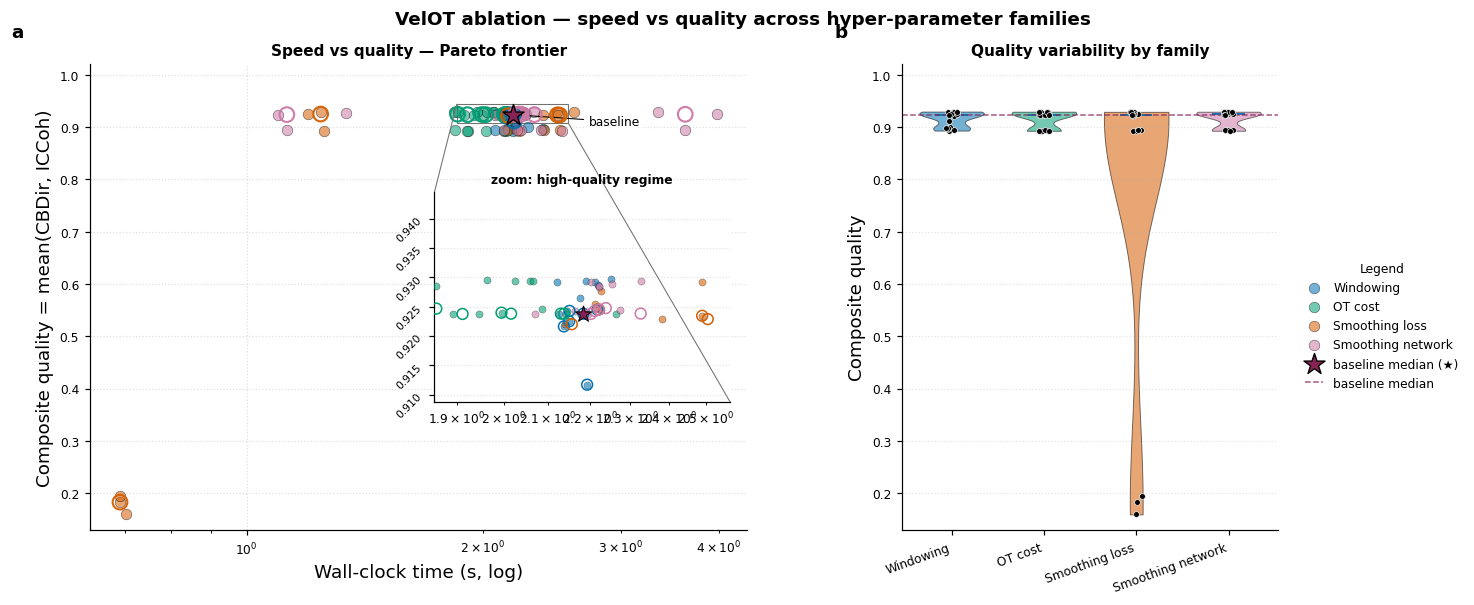

In [18]:
from matplotlib import gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

family_colour = {
    "Windowing":         WONG["blue"],
    "OT cost":           WONG["green"],
    "Smoothing loss":    WONG["orange"],
    "Smoothing network": WONG["magenta"],
}

fig = plt.figure(figsize=(13.5, 5.8))
gs  = gridspec.GridSpec(
    1, 2, figure=fig, width_ratios=[1.75, 1.0],
    wspace=0.30, left=0.06, right=0.86, top=0.91, bottom=0.18,
)

# ---------- (a) Pareto ----------
ax = fig.add_subplot(gs[0, 0])
panel_label(ax, "a", x=-0.12)

# Scatter all individual seed runs
for fam, col in family_colour.items():
    sub = ok[ok["family"].eq(fam)].copy()
    ax.scatter(
        sub["time_total"], sub["quality_mean"],
        s=48, color=col, alpha=0.55,
        edgecolor="black", linewidth=0.4, label=fam, zorder=3,
    )

# Add ablation medians with open markers so seed cloud and central tendency are separated.
med = (
    ok.groupby(["family", "name"], as_index=False)
      [["time_total", "quality_mean"]].median()
      .sort_values("quality_mean", ascending=False)
)
for fam, col in family_colour.items():
    sub = med[med["family"].eq(fam)]
    ax.scatter(
        sub["time_total"], sub["quality_mean"],
        s=92, facecolor="none", edgecolor=col, linewidth=1.4,
        alpha=0.95, zorder=5,
    )

# Highlight baseline
base = ok.query("name == 'baseline'")
if len(base):
    bx, by = base["time_total"].median(), base["quality_mean"].median()
    ax.scatter(
        [bx], [by], s=210, marker="*", color=WONG["red"],
        edgecolor="black", linewidth=0.9, zorder=10, label="baseline median (★)",
    )
    ax.annotate(
        "baseline", xy=(bx, by), xytext=(bx * 1.25, by - 0.020),
        arrowprops=dict(arrowstyle="->", lw=0.7, color="black"),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.18", facecolor="white",
                  edgecolor="none", alpha=0.8),
    )

# Annotate selected median points. Keep labels sparse to preserve readability.
labels_to_show = {
    "raw_OT_no_MLP", "unsup_KMeans_spatial", "no_time_penalty",
    "no_knn_penalty", "curl_0p5", "divergence_0p1", "no_pt_conditioning",
    "epochs_600", "hidden_256",
}
# for _, r in med.iterrows():
#     if r["name"] in labels_to_show and r["name"] != "baseline":
#         ax.annotate(
#             r["name"], (r["time_total"], r["quality_mean"]),
#             xytext=(6, 4), textcoords="offset points",
#             fontsize=7, alpha=0.90,
#             bbox=dict(boxstyle="round,pad=0.18", facecolor="white",
#                       edgecolor="grey", alpha=0.75, lw=0.35),
#             zorder=11,
#         )

ax.set_xscale("log")
ax.set_xlabel("Wall-clock time (s, log)")
ax.set_ylabel("Composite quality = mean(CBDir, ICCoh)")
ax.set_title("Speed vs quality — Pareto frontier")
ax.set_ylim(min(0.45, ok["quality_mean"].min() - 0.03), 1.02)
ax.grid(ls=":", alpha=0.4, zorder=0)

# Zoom window / inset: automatically focus on the dense high-quality operating regime.
# This makes small but biologically relevant differences visible without hiding outliers.
positive_times = ok.loc[ok["time_total"] > 0, "time_total"].values
qualities = ok["quality_mean"].dropna().values
if len(positive_times) >= 5 and len(qualities) >= 5:
    xlo, xhi = np.quantile(positive_times, [0.20, 0.90])
    ylo, yhi = np.quantile(qualities, [0.45, 0.98])
    # Add padding in log-x and linear-y coordinates.
    logxlo, logxhi = np.log10(max(xlo, 1e-6)), np.log10(max(xhi, xlo * 1.01))
    xpad = max((logxhi - logxlo) * 0.12, 0.02)
    ypad = max((yhi - ylo) * 0.20, 0.015)
    zxlo, zxhi = 10 ** (logxlo - xpad), 10 ** (logxhi + xpad)
    zylo, zyhi = max(0.0, ylo - ypad), min(1.02, yhi + ypad)

    axins = inset_axes(ax, width="45%", height="45%", loc="center right", borderpad=1.4)
    for fam, col in family_colour.items():
        sub = ok[ok["family"].eq(fam)]
        axins.scatter(
            sub["time_total"], sub["quality_mean"],
            s=22, color=col, alpha=0.58,
            edgecolor="black", linewidth=0.25, zorder=3,
        )
        subm = med[med["family"].eq(fam)]
        axins.scatter(
            subm["time_total"], subm["quality_mean"],
            s=50, facecolor="none", edgecolor=col, linewidth=1.0, zorder=5,
        )
    if len(base):
        axins.scatter([bx], [by], s=120, marker="*", color=WONG["red"],
                      edgecolor="black", linewidth=0.7, zorder=8)
    axins.set_xscale("log")
    axins.set_xlim(zxlo, zxhi)
    axins.set_ylim(zylo, zyhi)
    axins.set_title("zoom: high-quality regime", fontsize=8)
    axins.tick_params(labelsize=7, labelrotation=45)
    axins.grid(ls=":", alpha=0.35)
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.45", lw=0.7)

# ---------- (b) per-family quality distribution ----------
ax = fig.add_subplot(gs[0, 1])
panel_label(ax, "b", x=-0.18)
fams = list(ABLATION_FAMILIES.keys())
data = [ok.loc[ok["family"].eq(f), "quality_mean"].dropna().values for f in fams]
vp = ax.violinplot(data, positions=range(len(fams)), widths=0.7,
                   showmedians=True, showextrema=False)
for pc, f in zip(vp["bodies"], fams):
    pc.set_facecolor(family_colour[f]); pc.set_edgecolor("black")
    pc.set_alpha(0.55); pc.set_linewidth(0.6)
rng = np.random.default_rng(12345)
for i, vals in enumerate(data):
    ax.scatter(
        np.full(len(vals), i) + rng.uniform(-0.07, 0.07, len(vals)),
        vals, color="black", s=14, zorder=5,
        edgecolor="white", linewidth=0.4,
    )
ax.set_xticks(range(len(fams)))
ax.set_xticklabels(fams, rotation=20, ha="right")
ax.set_ylim(min(0.45, ok["quality_mean"].min() - 0.03), 1.02)
ax.axhline(
    ok.query("name == 'baseline'")["quality_mean"].median(),
    ls="--", color=WONG["red"], lw=1, alpha=0.75, label="baseline median",
)
ax.set_ylabel("Composite quality")
ax.set_title("Quality variability by family")
ax.grid(axis="y", ls=":", alpha=0.35)

# One clean external legend; nothing covers points.
handles, labels = [], []
for a in [fig.axes[0], ax]:
    h, l = a.get_legend_handles_labels()
    handles.extend(h); labels.extend(l)
unique = {}
for h, l in zip(handles, labels):
    unique.setdefault(l, h)
fig.legend(
    unique.values(), unique.keys(),
    loc="center left", bbox_to_anchor=(0.875, 0.50),
    fontsize=8, title="Legend", title_fontsize=8,
    frameon=False, borderaxespad=0.0,
)

fig.suptitle(
    "VelOT ablation — speed vs quality across hyper-parameter families",
    fontsize=12, fontweight="bold", y=0.995,
)
savefig(fig, "nb2_v3_pareto_and_family")
plt.show()

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_speed_quality_a.{pdf,png}


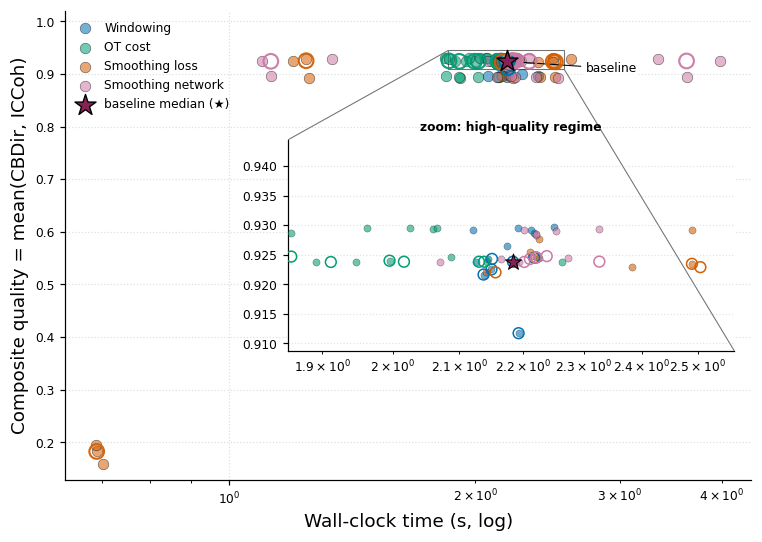

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_speed_quality_b.{pdf,png}


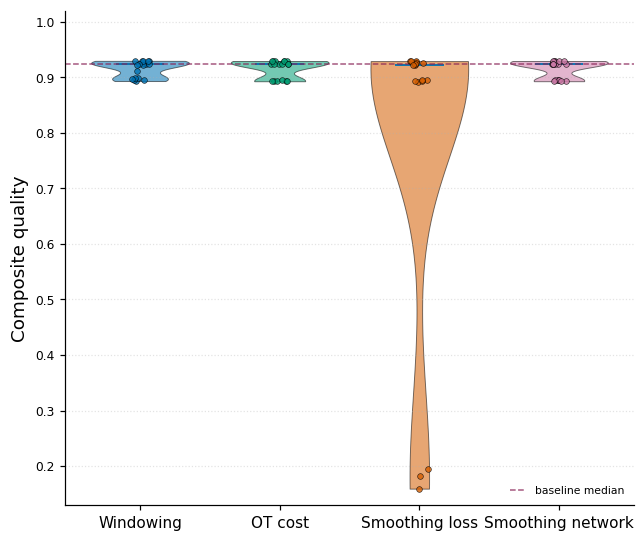

In [44]:
# ---------- (a) Pareto ----------
fig, ax = plt.subplots(figsize=(7.0, 5.0))

for fam, col in family_colour.items():
    sub = ok[ok["family"].eq(fam)].copy()
    ax.scatter(
        sub["time_total"], sub["quality_mean"],
        s=48, color=col, alpha=0.55,
        edgecolor="black", linewidth=0.4, label=fam, zorder=3,
    )

med = (
    ok.groupby(["family", "name"], as_index=False)
      [["time_total", "quality_mean"]].median()
      .sort_values("quality_mean", ascending=False)
)
for fam, col in family_colour.items():
    sub = med[med["family"].eq(fam)]
    ax.scatter(
        sub["time_total"], sub["quality_mean"],
        s=92, facecolor="none", edgecolor=col, linewidth=1.4,
        alpha=0.95, zorder=5,
    )

base = ok.query("name == 'baseline'")
if len(base):
    bx, by = base["time_total"].median(), base["quality_mean"].median()
    ax.scatter(
        [bx], [by], s=210, marker="*", color=WONG["red"],
        edgecolor="black", linewidth=0.9, zorder=10, label="baseline median (★)",
    )
    ax.annotate(
        "baseline", xy=(bx, by), xytext=(bx * 1.25, by - 0.020),
        arrowprops=dict(arrowstyle="->", lw=0.7, color="black"),
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.18", facecolor="white",
                  edgecolor="none", alpha=0.8),
    )

ax.set_xscale("log")
ax.set_xlabel("Wall-clock time (s, log)")
ax.set_ylabel("Composite quality = mean(CBDir, ICCoh)")
ax.set_ylim(min(0.45, ok["quality_mean"].min() - 0.03), 1.02)
ax.grid(ls=":", alpha=0.4, zorder=0)
ax.legend(loc="upper left", fontsize=8, frameon=False)

positive_times = ok.loc[ok["time_total"] > 0, "time_total"].values
qualities = ok["quality_mean"].dropna().values
if len(positive_times) >= 5 and len(qualities) >= 5:
    xlo, xhi = np.quantile(positive_times, [0.20, 0.90])
    ylo, yhi = np.quantile(qualities, [0.45, 0.98])
    logxlo, logxhi = np.log10(max(xlo, 1e-6)), np.log10(max(xhi, xlo * 1.01))
    xpad = max((logxhi - logxlo) * 0.12, 0.02)
    ypad = max((yhi - ylo) * 0.20, 0.015)
    zxlo, zxhi = 10 ** (logxlo - xpad), 10 ** (logxhi + xpad)
    zylo, zyhi = max(0.0, ylo - ypad), min(1.02, yhi + ypad)

    axins = inset_axes(ax, width="65%", height="45%", loc="center right", borderpad=1.4)
    for fam, col in family_colour.items():
        sub = ok[ok["family"].eq(fam)]
        axins.scatter(
            sub["time_total"], sub["quality_mean"],
            s=22, color=col, alpha=0.58,
            edgecolor="black", linewidth=0.25, zorder=3,
        )
        subm = med[med["family"].eq(fam)]
        axins.scatter(
            subm["time_total"], subm["quality_mean"],
            s=50, facecolor="none", edgecolor=col, linewidth=1.0, zorder=5,
        )
    if len(base):
        axins.scatter([bx], [by], s=120, marker="*", color=WONG["red"],
                      edgecolor="black", linewidth=0.7, zorder=8)
    axins.set_xscale("log")
    axins.set_xlim(zxlo, zxhi)
    axins.set_ylim(zylo, zyhi)
    axins.set_title("zoom: high-quality regime", fontsize=8)
    axins.tick_params(labelsize=8)
    axins.grid(ls=":", alpha=0.35)
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.45", lw=0.7)

plt.tight_layout()
savefig(fig, "ablation_speed_quality_a")
plt.show()

# ---------- (b) per-family quality distribution ----------
fig, ax = plt.subplots(figsize=(6.0, 5.0))
fams = list(ABLATION_FAMILIES.keys())
data = [ok.loc[ok["family"].eq(f), "quality_mean"].dropna().values for f in fams]
vp = ax.violinplot(data, positions=range(len(fams)), widths=0.7,
                   showmedians=True, showextrema=False)

fam_colors = []
for pc, f in zip(vp["bodies"], fams):
    col = family_colour[f]
    pc.set_facecolor(col); pc.set_edgecolor("black")
    pc.set_alpha(0.55); pc.set_linewidth(0.6)
    fam_colors.append(col)

rng = np.random.default_rng(12345)
for i, (vals, col) in enumerate(zip(data, fam_colors)):
    ax.scatter(
        np.full(len(vals), i) + rng.uniform(-0.07, 0.07, len(vals)),
        vals, s=14, zorder=5, linewidth=0.4, alpha=0.8,
        color=col, edgecolor="black",
    )
ax.set_xticks(range(len(fams)))
ax.set_xticklabels(fams, fontsize=10)
ax.set_ylim(min(0.45, ok["quality_mean"].min() - 0.03), 1.02)
ax.axhline(
    ok.query("name == 'baseline'")["quality_mean"].median(),
    ls="--", color=WONG["red"], lw=1, alpha=0.75, label="baseline median",
)
ax.set_ylabel("Composite quality")
ax.grid(axis="y", ls=":", alpha=0.35)
ax.legend(loc="lower right", fontsize=7, frameon=False)
plt.tight_layout()
savefig(fig, "ablation_speed_quality_b")
plt.show()

## 5. Composite Figure 2 - family-grouped bar charts

Four panels (one per family). For each ablation in the family we show CBDir, ICCoh and
the composite quality as side-by-side bars (mean ± SD across seeds), with the baseline
horizontal lines clearly marked.

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_family_a.{pdf,png}


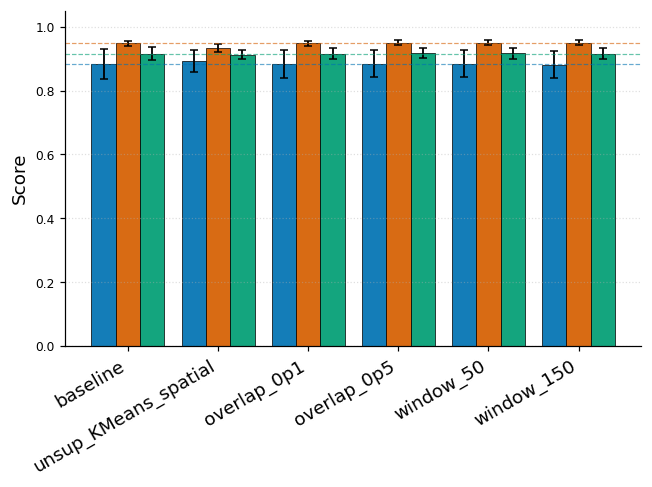

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_family_b.{pdf,png}


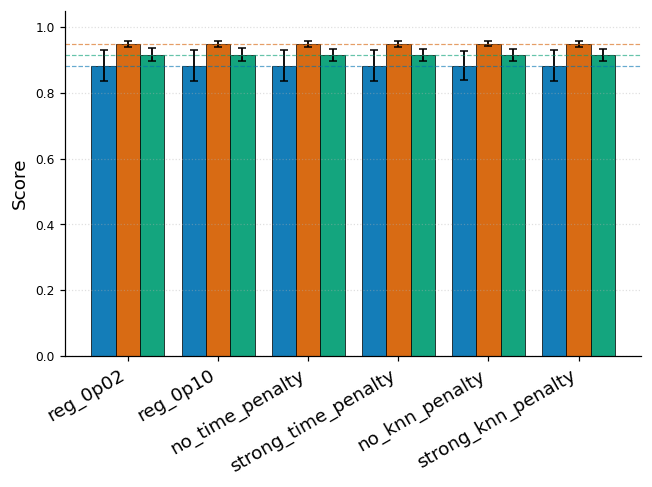

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_family_c.{pdf,png}


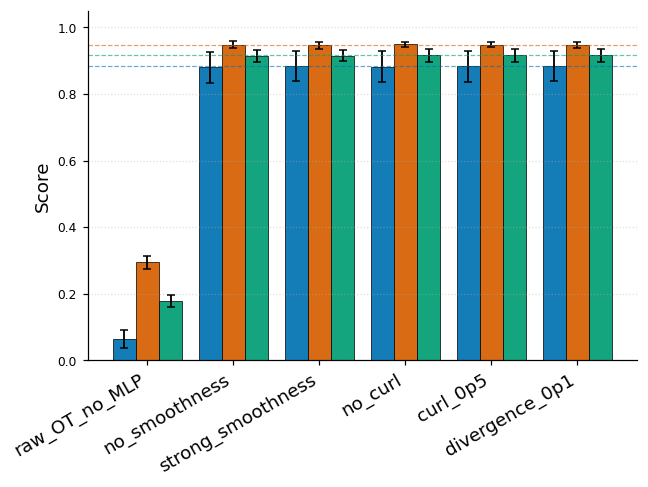

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_family_d.{pdf,png}


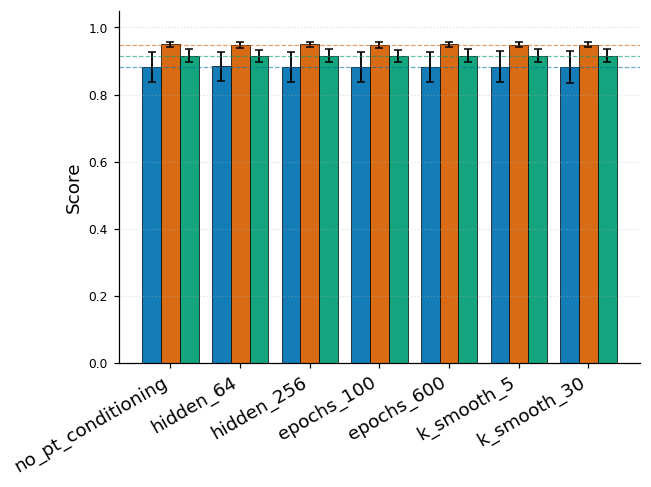

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_family_legend.png.{pdf,png}
Saved ablation_family_legend.png


In [47]:
base_q = ok.query("name == 'baseline'")[["cbdir_mean","iccoh_mean","quality_mean"]].mean()

metric_info = [
    ("cbdir_mean",   "CBDir",   WONG["blue"]),
    ("iccoh_mean",   "ICCoh",   WONG["orange"]),
    ("quality_mean", "Quality", WONG["green"]),
]

labels_list = ["a", "b", "c", "d"]

for label, (fam, items) in zip(labels_list, ABLATION_FAMILIES.items()):
    fig, ax = plt.subplots(figsize=(6.0, 4.5))
    names_in_fam = [n for n, _ in items]
    sub = ok[ok["name"].isin(names_in_fam)].copy()
    g = (sub.groupby("name")[["cbdir_mean", "iccoh_mean", "quality_mean"]]
            .agg(["mean", "std"]))
    g = g.reindex(names_in_fam)
    xs = np.arange(len(names_in_fam))
    width = 0.27
    for off, (col, lab, c) in enumerate(metric_info):
        means = g[(col, "mean")].values
        stds  = g[(col, "std")].values
        ax.bar(xs + (off - 1) * width, means, width, yerr=stds, capsize=2.5,
               color=c, edgecolor="black", linewidth=0.5, alpha=0.92)
        ax.axhline(base_q[col], color=c, ls="--", lw=0.8, alpha=0.6)
    ax.set_xticks(xs)
    ax.set_xticklabels(names_in_fam, rotation=30, ha="right", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", ls=":", alpha=0.4)
    plt.tight_layout()
    savefig(fig, f"ablation_family_{label}")
    plt.show()

# ---------- standalone legend ----------
fig_leg = plt.figure(figsize=(0.1, 0.1))
handles = []
for col, lab, c in metric_info:
    handles.append(plt.Rectangle((0, 0), 1, 1, facecolor=c,
                                  edgecolor="black", linewidth=0.5,
                                  alpha=0.92, label=lab))
# Add dashed line for baseline
handles.append(plt.Line2D([0], [0], ls="--", lw=1.2, color="black",
                           alpha=0.6, label="baseline"))
leg = fig_leg.legend(handles=handles, loc="center",
                     fontsize=10, frameon=False, ncol=len(handles))
fig_leg.canvas.draw()
bbox = leg.get_window_extent().transformed(fig_leg.dpi_scale_trans.inverted())
savefig(fig_leg, "ablation_family_legend.png")
plt.close(fig_leg)
print("Saved ablation_family_legend.png")

## 6. Composite Figure 3 - normalised metric heatmap

Each column is a metric (CBDir, ICCoh, future-alignment, confidence, low-zero confidence,
speed). Values are min-max normalised so that **larger = better** (we invert *time* and
*confidence_zero_frac*). Rows are ordered by family and then by composite quality
descending.

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_heatmap.{pdf,png}


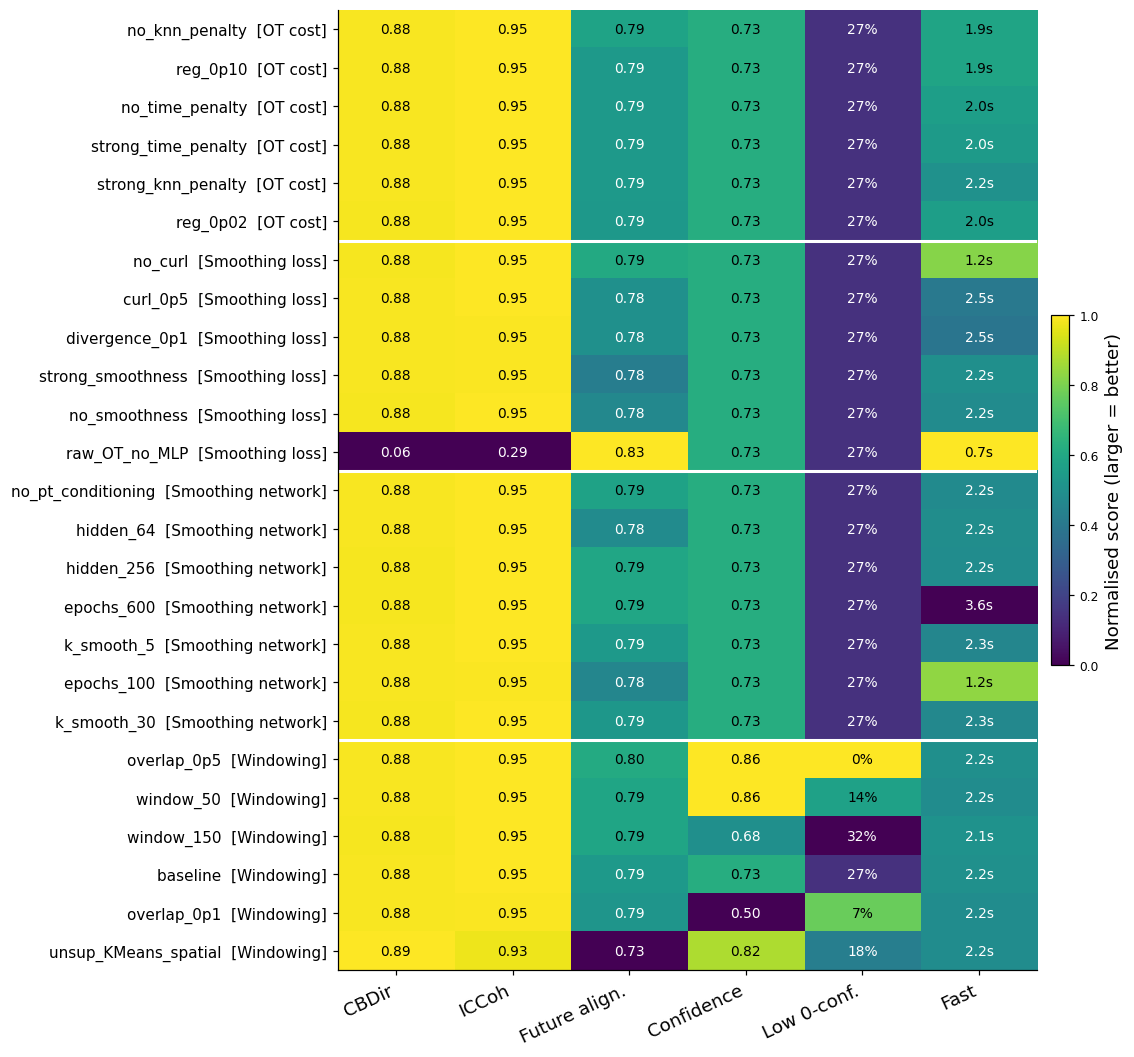

In [55]:
plot_cols = ["cbdir_mean_mean", "iccoh_mean_mean", "future_alignment_mean",
             "confidence_mean_mean", "confidence_zero_frac_mean", "time_total_mean"]
nice = {"cbdir_mean_mean": "CBDir", "iccoh_mean_mean": "ICCoh",
        "future_alignment_mean": "Future align.",
        "confidence_mean_mean": "Confidence",
        "confidence_zero_frac_mean": "Low 0-conf.", "time_total_mean": "Fast"}
hm = summary.set_index(["family", "name"])[plot_cols].astype(float).copy()
hm_norm = hm.copy()
for col in hm_norm.columns:
    x = hm_norm[col]
    rng = x.max() - x.min()
    hm_norm[col] = (x - x.min()) / rng if rng > 1e-12 else 0.5
# Invert metrics where smaller-is-better
for col in ["time_total_mean", "confidence_zero_frac_mean"]:
    hm_norm[col] = 1 - hm_norm[col]
hm_norm = hm_norm.rename(columns=nice)

# Cell dimensions: figsize controls total size, aspect controls cell shape
# Smaller width per column, larger height per row
cell_width = 1.2   # inches per column
cell_height = 0.3  # inches per row
n_rows, n_cols = hm_norm.shape

fig, ax = plt.subplots(
    figsize=(n_cols * cell_width + 3, n_rows * cell_height + 2),
    constrained_layout=True,
)

im = ax.imshow(hm_norm.values, aspect=cell_height / cell_width, cmap="viridis", vmin=0, vmax=1)

# fig, ax = plt.subplots(figsize=(10, max(7, 0.32 * len(hm_norm))),
#                         constrained_layout=True)
im = ax.imshow(hm_norm.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(hm_norm.columns)))
ax.set_xticklabels(hm_norm.columns, rotation=25, ha="right", fontsize=12)
ylabels = [f"{n}  [{f}]" for f, n in hm_norm.index]
ax.set_yticks(range(len(hm_norm)))
ax.set_yticklabels(ylabels, fontsize=10)
# Annotate raw (un-normalised) values for biological interpretability
raw = hm.rename(columns=nice)
for i in range(hm_norm.shape[0]):
    for j in range(hm_norm.shape[1]):
        v_norm = hm_norm.values[i, j]
        v_raw  = raw.values[i, j]
        txt_col = "white" if v_norm < 0.55 else "black"
        if hm_norm.columns[j] == "Fast":   text = f"{v_raw:.1f}s"
        elif hm_norm.columns[j] == "Low 0-conf.": text = f"{v_raw*100:.0f}%"
        else:                              text = f"{v_raw:.2f}"
        ax.text(j, i, text, ha="center", va="center",
                fontsize=9, color=txt_col)
# Family separators
fam_starts = []
prev = None
for k, (fam, _) in enumerate(hm_norm.index):
    if prev is not None and fam != prev: fam_starts.append(k)
    prev = fam
for k in fam_starts:
    ax.axhline(k - 0.5, color="white", lw=2)
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("Normalised score (larger = better)")
# ax.set_title("Ablation metric heatmap (normalised; raw values annotated), fontsize=11, fontweight="bold")
savefig(fig, "ablation_heatmap")
plt.show()

## 7. Composite Figure 4 — distribution + exact paired tests vs baseline

For a curated set of high-interest ablations, we plot per-seed metric distributions.
Because `REPEATS` is small and the experimental design is paired by seed, v3 uses an
**exact paired sign-flip permutation test** on the within-seed differences against the
baseline rather than an asymptotic Wilcoxon approximation. Benjamini-Hochberg correction
is applied separately per metric across the non-baseline ablations.

Interpretation note: with only a few paired seeds, exact p-values are intentionally
conservative and coarse. Therefore the figure reports `ns` and q-values explicitly, and
the saved table should be used together with the paired effect sizes (`delta_mean`,
`delta_median`, `cohen_dz`).


### Figure 4: curated ablation summary with robust paired-test labels

This version fixes the previous `KeyError: 'name'` by keeping the ablation name as both the index and a column, and by passing the name explicitly to the q-value label helper. The figure layout and analyses are otherwise unchanged.


In [63]:
from itertools import product

curated = ["baseline", "raw_OT_no_MLP", "unsup_KMeans_spatial",
           "no_time_penalty", "no_knn_penalty", "no_pt_conditioning",
           "curl_0p5", "divergence_0p1", "overlap_0p5", "window_50",
           "window_150", "epochs_100", "epochs_600"]
sel = ok[ok["name"].isin(curated)].copy()
sel["name"] = pd.Categorical(sel["name"], categories=curated, ordered=True)
sel = sel.sort_values(["name", "seed"])

def exact_signflip_pvalue(diff, alternative="two-sided", max_exact_n=20,
                          n_random=200_000, random_state=123):
    """
    Exact paired randomisation/sign-flip test for paired seed differences.

    Null hypothesis: the sign of each within-seed difference is exchangeable.
    Statistic: mean paired difference. For n <= max_exact_n all 2^n sign flips
    are enumerated; otherwise a Monte-Carlo approximation is used.
    """
    d = np.asarray(diff, dtype=float)
    d = d[np.isfinite(d)]
    n = len(d)
    if n == 0:
        return np.nan
    if np.allclose(d, 0):
        return 1.0

    obs = float(np.mean(d))

    if n <= max_exact_n:
        signs = np.array(list(product([-1.0, 1.0], repeat=n)), dtype=float)
        null_stats = signs.dot(d) / n
    else:
        rng = np.random.default_rng(random_state)
        signs = rng.choice([-1.0, 1.0], size=(n_random, n), replace=True)
        null_stats = signs.dot(d) / n

    if alternative == "greater":
        p = np.mean(null_stats >= obs - 1e-15)
    elif alternative == "less":
        p = np.mean(null_stats <= obs + 1e-15)
    else:
        p = np.mean(np.abs(null_stats) >= abs(obs) - 1e-15)

    return float(max(p, 1.0 / len(null_stats)))

def bh_adjust(pvals):
    """Benjamini-Hochberg correction with NaN preservation."""
    p = np.asarray(pvals, dtype=float)
    q = np.full_like(p, np.nan, dtype=float)
    valid = np.isfinite(p)
    if not np.any(valid):
        return q
    pv = p[valid]
    order = np.argsort(pv)
    ranked = pv[order] * len(pv) / np.arange(1, len(pv) + 1)
    q_sorted = np.minimum.accumulate(ranked[::-1])[::-1]
    qv = np.empty_like(pv)
    qv[order] = np.clip(q_sorted, 0, 1)
    q[valid] = qv
    return q

def paired_exact_vs_baseline(metric):
    base = (
        sel.loc[sel["name"].eq("baseline"), ["seed", metric]]
           .rename(columns={metric: "baseline"})
           .dropna()
    )
    rows = []
    for nm in curated:
        if nm == "baseline":
            rows.append(dict(
                name=nm, n_pairs=len(base), delta_mean=0.0, delta_median=0.0,
                cohen_dz=np.nan, p_raw=np.nan,
            ))
            continue

        cur = (
            sel.loc[sel["name"].eq(nm), ["seed", metric]]
               .rename(columns={metric: "ablation"})
               .dropna()
        )
        pair = pd.merge(base, cur, on="seed", how="inner").sort_values("seed")
        diff = pair["ablation"].to_numpy(dtype=float) - pair["baseline"].to_numpy(dtype=float)
        diff = diff[np.isfinite(diff)]
        n = len(diff)
        if n >= 2:
            p_raw = exact_signflip_pvalue(diff, alternative="two-sided")
            delta_mean = float(np.mean(diff))
            delta_median = float(np.median(diff))
            sd = float(np.std(diff, ddof=1)) if n > 1 else np.nan
            cohen_dz = float(delta_mean / sd) if np.isfinite(sd) and sd > 0 else np.nan
        else:
            p_raw = np.nan
            delta_mean = np.nan
            delta_median = np.nan
            cohen_dz = np.nan
        rows.append(dict(
            name=nm, n_pairs=n, delta_mean=delta_mean,
            delta_median=delta_median, cohen_dz=cohen_dz, p_raw=p_raw,
        ))

    df = pd.DataFrame(rows)
    mask = ~df["name"].eq("baseline")
    df.loc[mask, "p_bh"] = bh_adjust(df.loc[mask, "p_raw"].to_numpy())
    df.loc[~mask, "p_bh"] = np.nan
    df["stars"] = df["p_bh"].apply(lambda p: stars(p) if np.isfinite(p) else "ref")
    return df

tests = {}
for m in ("cbdir_mean", "iccoh_mean", "future_alignment", "time_total"):
    tests[m] = paired_exact_vs_baseline(m)

tests_combined = pd.concat([df.assign(metric=m) for m, df in tests.items()])
tests_combined.to_csv(TABLEDIR / "nb2_v5_exact_paired_tests.csv", index=False)
display(tests_combined.head(20))

def q_label(row, nm=None):
    """Robust q-value label for rows indexed by ablation name.

    Pandas drops the `name` column after `set_index("name")` unless
    `drop=False` is used. This helper therefore accepts the ablation name
    explicitly and also falls back to row.name, preventing KeyError: 'name'.
    """
    if nm is None:
        nm = row.get("name", getattr(row, "name", None))
    if str(nm) == "baseline":
        return "ref"
    p_bh = row.get("p_bh", np.nan)
    if not np.isfinite(p_bh):
        return "n/a"
    return f"{row.get('stars', 'ns')}\nq={p_bh:.2g}"

,name,n_pairs,delta_mean,delta_median,cohen_dz,p_raw,p_bh,stars,metric
0,baseline,3,0.000000,0.000000,NaN,NaN,NaN,ref,cbdir_mean
1,raw_OT_no_MLP,3,-0.818599,-0.854344,-11.333779,0.25,1.000000,ns,cbdir_mean
2,unsup_KMeans_spatial,3,0.009421,0.003420,0.721678,0.25,1.000000,ns,cbdir_mean
3,no_time_penalty,3,0.000000,0.000000,NaN,1.00,1.000000,ns,cbdir_mean
4,no_knn_penalty,3,-0.000131,-0.000619,-0.060579,1.00,1.000000,ns,cbdir_mean
5,no_pt_conditioning,3,0.000377,-0.000167,0.263355,1.00,1.000000,ns,cbdir_mean
6,curl_0p5,3,0.000353,0.000250,0.558422,0.50,1.000000,ns,cbdir_mean
7,divergence_0p1,3,0.000831,-0.000038,0.532605,1.00,1.000000,ns,cbdir_mean
8,overlap_0p5,3,0.001990,-0.000396,0.406138,1.00,1.000000,ns,cbdir_mean
9,window_50,3,0.001390,-0.000175,0.331882,1.00,1.000000,ns,cbdir_mean


saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_test_baseline_a.{pdf,png}


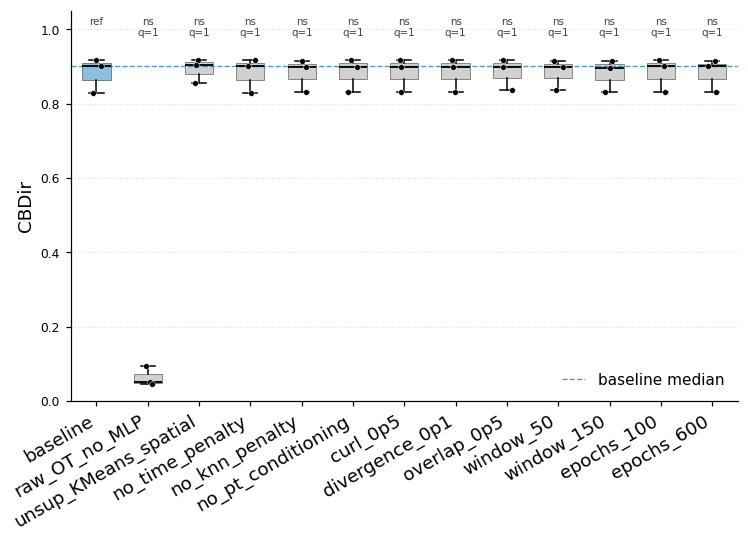

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_test_baseline_b.{pdf,png}


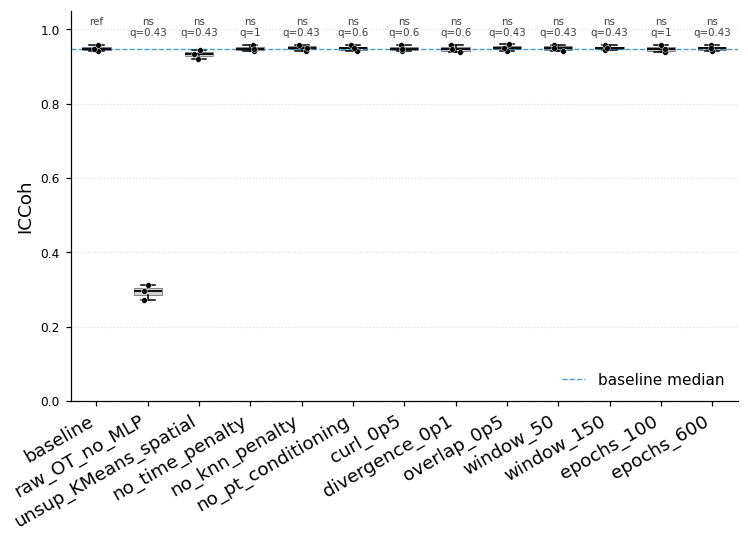

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_test_baseline_c.{pdf,png}


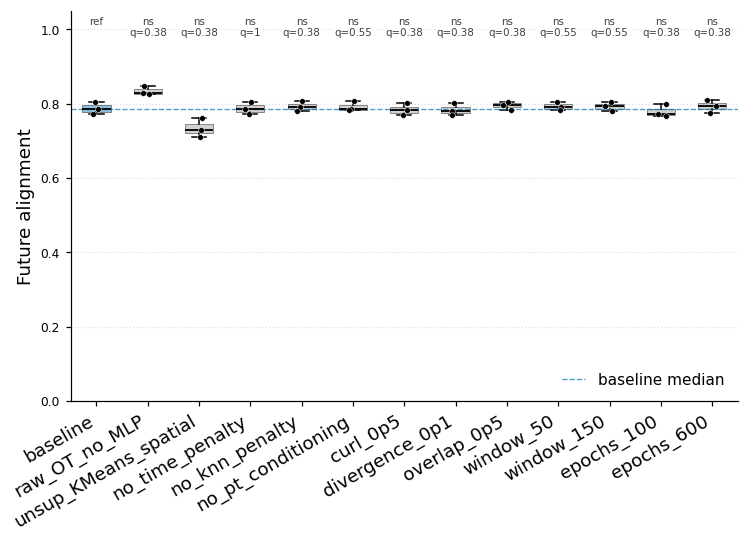

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_test_baseline_d.{pdf,png}


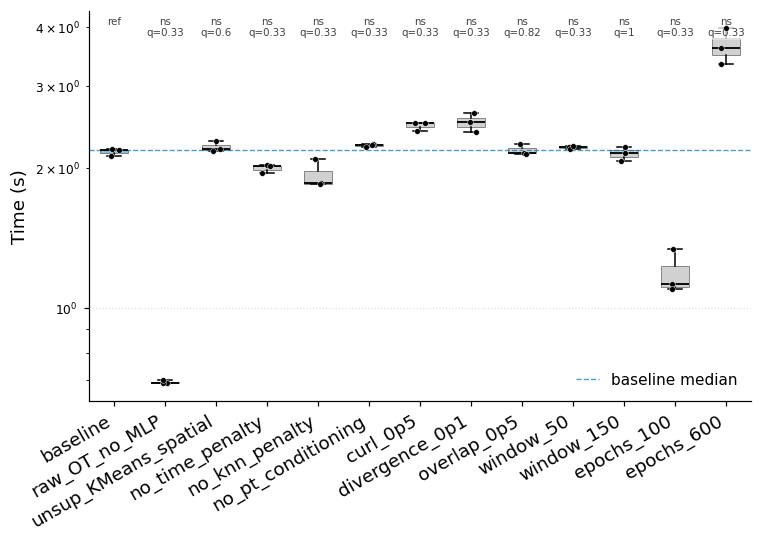

In [65]:
metrics_to_plot = [("cbdir_mean", "CBDir", False),
                   ("iccoh_mean", "ICCoh", False),
                   ("future_alignment", "Future alignment", False),
                   ("time_total", "Time (s)", True)]

labels_list = ["a", "b", "c", "d"]
rng = np.random.default_rng(202405)

for label, (metric, ylabel, log) in zip(labels_list, metrics_to_plot):
    fig, ax = plt.subplots(figsize=(7,5))
    data = [sel.query("name == @nm")[metric].dropna().values for nm in curated]
    bp = ax.boxplot(data, positions=range(len(curated)), widths=0.55,
                    patch_artist=True, showfliers=False, zorder=2)
    for patch, nm in zip(bp["boxes"], curated):
        col = WONG["blue"] if nm == "baseline" else WONG["grey"]
        patch.set_facecolor(col); patch.set_alpha(0.45)
        patch.set_edgecolor("black"); patch.set_linewidth(0.6)
    for medline in bp["medians"]:
        medline.set_color("black"); medline.set_linewidth(1.2)

    for i, vals in enumerate(data):
        ax.scatter(
            np.full(len(vals), i) + rng.uniform(-0.10, 0.10, len(vals)),
            vals, color="black", s=14, zorder=5,
            edgecolor="white", linewidth=0.3,
        )

    base_med = sel.query("name == 'baseline'")[metric].median()
    if np.isfinite(base_med):
        ax.axhline(base_med, ls="--", color=WONG["blue"], lw=0.9,
                   alpha=0.7, label="baseline median")

    if log:
        ax.set_yscale("log")
    else:
        ax.set_ylim(0, 1.05)

    tdf = tests[metric].set_index("name", drop=False)
    for i, nm in enumerate(curated):
        row = tdf.loc[nm]
        txt = q_label(row, nm)
        color = WONG["blue"] if (nm != "baseline" and row.get("stars") != "ns") else "0.25"
        ax.text(
            i, 0.985, txt, transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=6.7,
            color=color, fontweight="bold" if color == WONG["blue"] else "normal",
            bbox=dict(boxstyle="round,pad=0.13", fc="white", ec="none", alpha=0.72),
        )

    ax.set_xticks(range(len(curated)))
    ax.set_xticklabels(curated, rotation=30, ha="right", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(axis="y", ls=":", alpha=0.4)
    ax.legend(loc="lower right", fontsize=10, frameon=False)
    plt.tight_layout()
    savefig(fig, f"ablation_test_baseline_{label}")
    plt.show()

## 8. Composite Figure 5 - velocity-field gallery

Streamline visualisation for selected ablations, side-by-side with the baseline. The
streamplot uses a regular grid (cleaner than per-cell quivers).

In [75]:
def umap_axis(ax, pos=(0.02, 0.02), length=0.15, fontsize=9):
    x0, y0 = pos
    ax.axis("off")
    ax.annotate("", xy=(x0 + length, y0), xytext=(x0, y0),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="->", lw=1.2, color="black"))
    ax.annotate("", xy=(x0, y0 + length), xytext=(x0, y0),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="->", lw=1.2, color="black"))
    ax.text(x0 + length, y0 - 0.02, "UMAP1",
            transform=ax.transAxes, ha="right", va="top", fontsize=fontsize)
    ax.text(x0 - 0.02, y0 + length, "UMAP2",
            transform=ax.transAxes, ha="right", va="top",
            rotation=90, fontsize=fontsize)

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_velocity_family_a.{pdf,png}


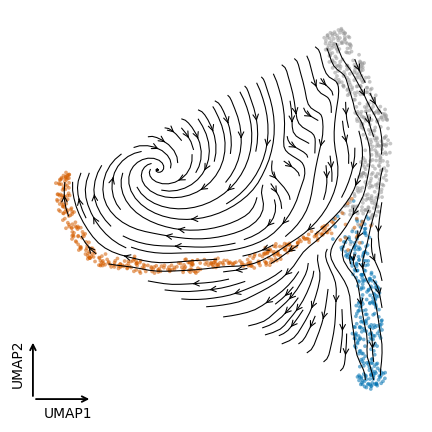

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_velocity_family_b.{pdf,png}


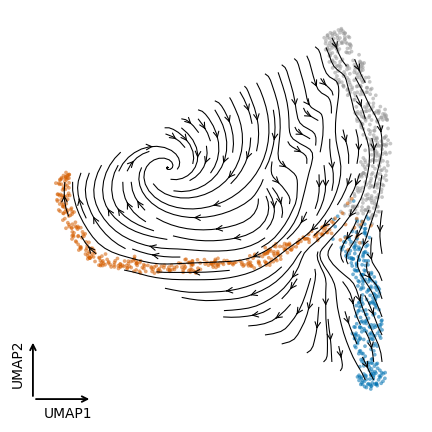

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_velocity_family_c.{pdf,png}


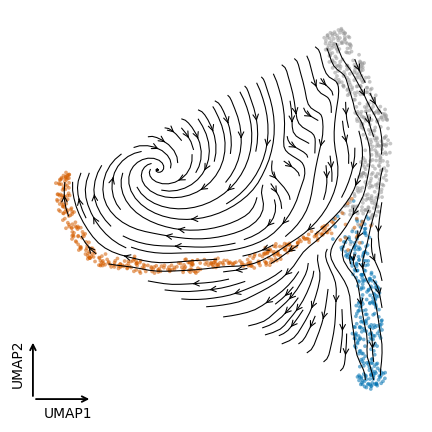

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_velocity_family_d.{pdf,png}


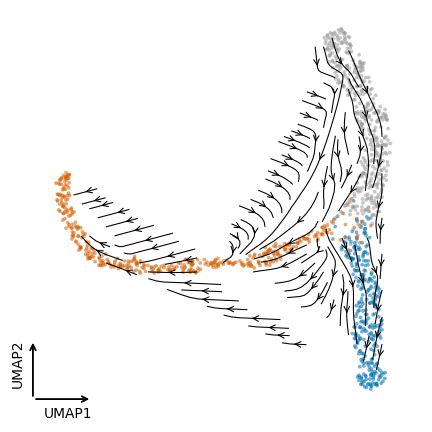

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_velocity_family_e.{pdf,png}


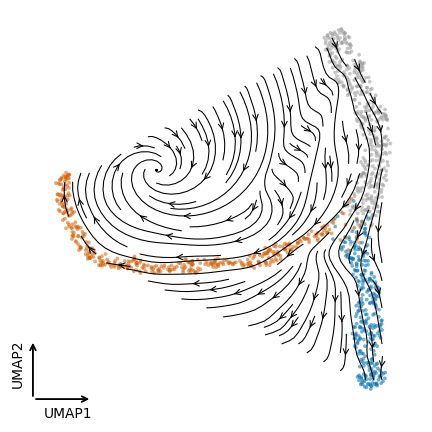

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_velocity_family_f.{pdf,png}


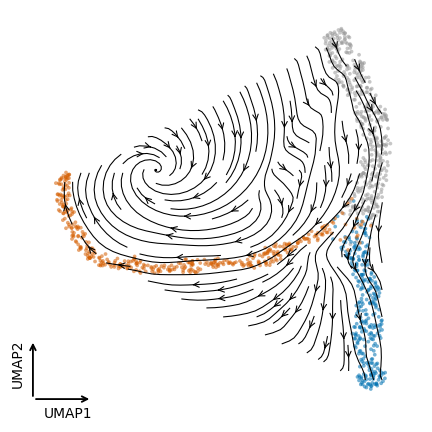

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_velocity_family_g.{pdf,png}


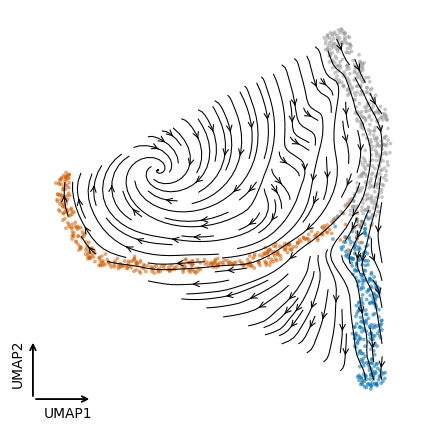

In [76]:
import math

labels = list(example_adatas.keys())
labels_list = [chr(ord("a") + i) for i in range(len(labels))]

for fig_label, name in zip(labels_list, labels):
    fig, ax = plt.subplots(figsize=(4, 4))
    a = example_adatas[name]
    vkey = "velot_velocity_umap" if "velot_velocity_umap" in a.obsm else "velot_velocity_raw_umap"
    streamline_panel(ax, a, velocity_key=vkey, density=1.5, ngrid=46, lw=0.7, s=6)
    umap_axis(ax)
    plt.tight_layout()
    savefig(fig, f"ablation_velocity_family_{fig_label}")
    plt.show()

## 9. Composite Figure 6 — smoothing convergence curves

If `velot.tl.smooth_velocity` stores per-loss histories in
`adata.uns["velot_smoothing"]`, we plot the **total**, **regression**,
**smoothness**, **curl** and **divergence** components separately.

v3 makes this plot zero-aware: components that contain zeros are plotted with a
`sym-log` scale rather than a pure log scale, so a true zero divergence loss is not
silently hidden. The `divergence_0p1` ablation is also kept in the example gallery so
the divergence penalty can be inspected directly.


saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/nb2_v3_loss_curves.{pdf,png}


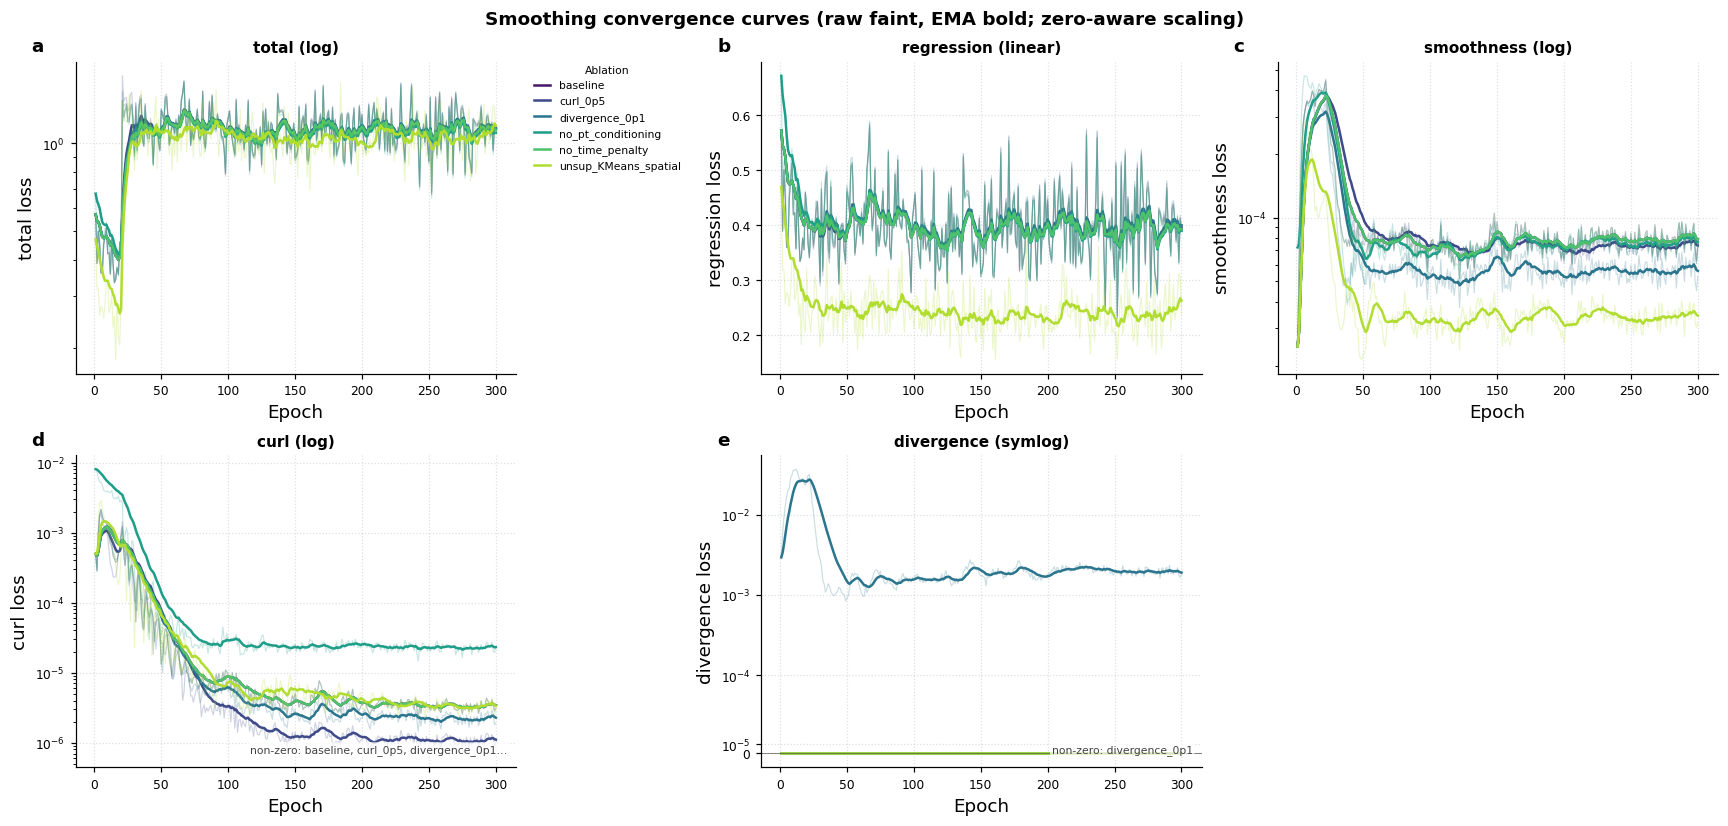

In [77]:

loss_records = []
for label, a in example_adatas.items():
    info = a.uns.get("velot_smoothing", {})
    for key in info:
        if key.startswith("losses_") and isinstance(info[key], (list, np.ndarray)):
            short = key.replace("losses_", "")
            for ep, v in enumerate(info[key]):
                if v is None:
                    continue
                try:
                    v = float(v)
                except Exception:
                    continue
                if np.isfinite(v):
                    loss_records.append(dict(name=label, epoch=ep + 1,
                                              component=short, loss=v))
loss_df = pd.DataFrame(loss_records)
loss_df.to_csv(TABLEDIR / "nb2_v3_loss_curves.csv", index=False)

def ema(x, alpha=0.15):
    x = np.asarray(x, dtype=float)
    if len(x) == 0:
        return x
    out = np.empty_like(x, dtype=float)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1 - alpha) * out[i - 1]
    return out

def choose_loss_scale(vals):
    """Choose a readable y-scale without hiding true zeros."""
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        return "linear", None
    if np.nanmax(np.abs(vals)) == 0:
        return "linear", None
    if np.any(vals <= 0):
        positive = vals[vals > 0]
        linthresh = max(np.nanmin(positive) / 10, 1e-10) if len(positive) else 1e-8
        return "symlog", linthresh
    ratio = np.nanmax(vals) / max(np.nanmin(vals), 1e-12)
    if ratio > 5:
        return "log", None
    return "linear", None

if len(loss_df):
    preferred = ["total", "regression", "smoothness", "curl", "divergence", "div"]
    present = list(loss_df["component"].unique())
    components = [c for c in preferred if c in present] + sorted([c for c in present if c not in preferred])

    ncols = min(3, len(components))
    nrows = math.ceil(len(components) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5.2 * ncols, 3.7 * nrows),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()
    names = sorted(loss_df["name"].unique())
    cmap = plt.cm.viridis(np.linspace(0.06, 0.88, len(names)))
    name_colour = dict(zip(names, cmap))

    for ax, comp in zip(axes, components):
        subc = loss_df[loss_df["component"].eq(comp)].copy()
        yscale, linthresh = choose_loss_scale(subc["loss"].values)

        for nm, g in subc.groupby("name"):
            g = g.sort_values("epoch")
            y = g["loss"].values.astype(float)
            ax.plot(g["epoch"], y, color=name_colour[nm], alpha=0.25, lw=0.75)
            ax.plot(g["epoch"], ema(y), color=name_colour[nm], lw=1.65, label=nm)

        if yscale == "log":
            ax.set_yscale("log")
        elif yscale == "symlog":
            ax.set_yscale("symlog", linthresh=linthresh, linscale=0.8)
            ax.axhline(0, color="0.35", lw=0.6, alpha=0.8)
        else:
            # If all values are exactly zero, give the axis a visible range.
            vals = subc["loss"].values
            if len(vals) and np.nanmax(np.abs(vals)) == 0:
                ax.set_ylim(-0.05, 0.05)
                ax.text(
                    0.5, 0.5, "all recorded values = 0",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=8, color="0.35",
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.8),
                )

        # Make divergence/curl panels self-documenting.
        if comp in {"divergence", "div", "curl"}:
            nonzero_by_name = (
                subc.groupby("name")["loss"]
                    .apply(lambda x: int(np.sum(np.asarray(x) > 0)))
                    .to_dict()
            )
            active = [k for k, v in nonzero_by_name.items() if v > 0]
            if active:
                ax.text(
                    0.98, 0.04,
                    "non-zero: " + ", ".join(active[:3]) + ("…" if len(active) > 3 else ""),
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=7, color="0.25",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                )

        ax.set_xlabel("Epoch")
        ax.set_ylabel(f"{comp} loss")
        ax.set_title(f"{comp} ({yscale})")
        ax.grid(ls=":", alpha=0.4)

    for ax in axes[len(components):]:
        ax.set_visible(False)

    axes[0].legend(
        loc="upper left", bbox_to_anchor=(1.02, 1.02),
        fontsize=7, title="Ablation", title_fontsize=7,
        frameon=False,
    )
    for i, ax in enumerate(axes[:len(components)]):
        panel_label(ax, "abcdefgh"[i], x=-0.10, y=1.02)

    fig.suptitle(
        "Smoothing convergence curves (raw faint, EMA bold; zero-aware scaling)",
        fontsize=12, fontweight="bold",
    )
    savefig(fig, "nb2_v3_loss_curves")
    plt.show()
else:
    print("No per-loss history was recorded by smooth_velocity in this run.")


saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_smoothing_convergence_a.{pdf,png}


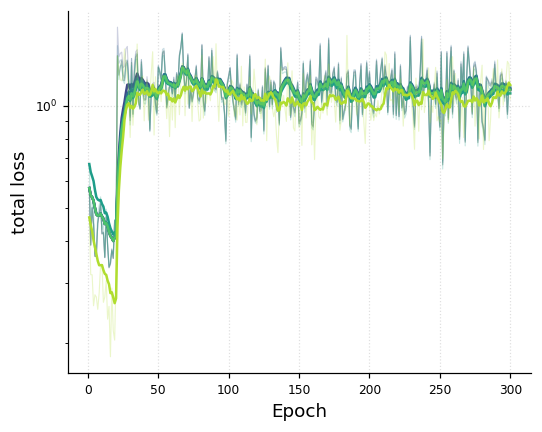

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_smoothing_convergence_b.{pdf,png}


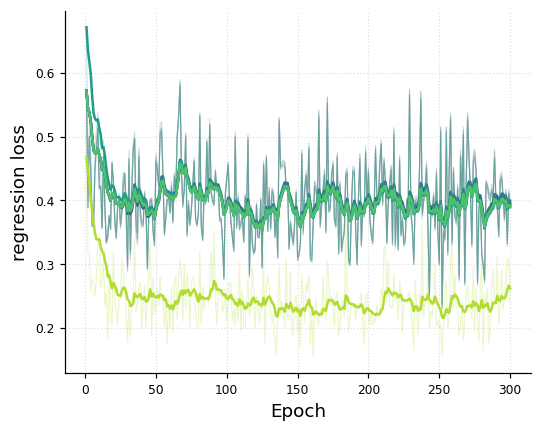

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_smoothing_convergence_c.{pdf,png}


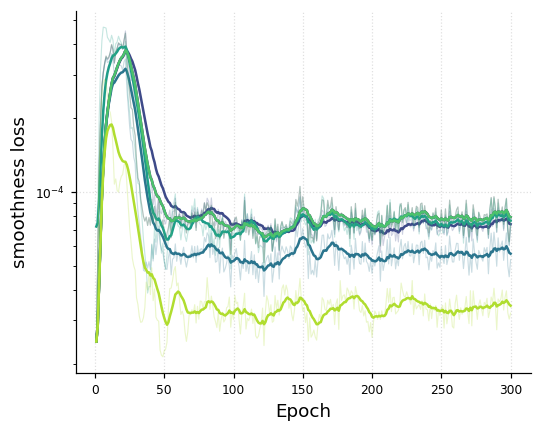

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_smoothing_convergence_d.{pdf,png}


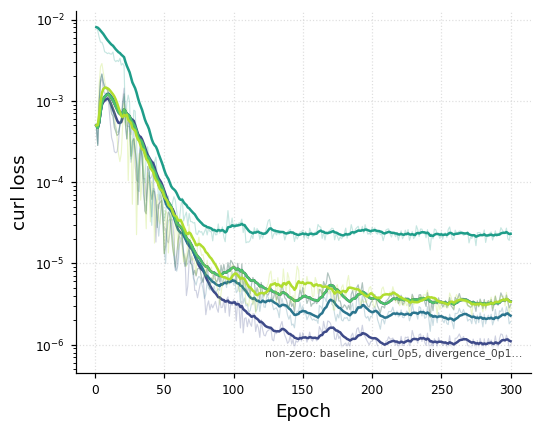

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_smoothing_convergence_e.{pdf,png}


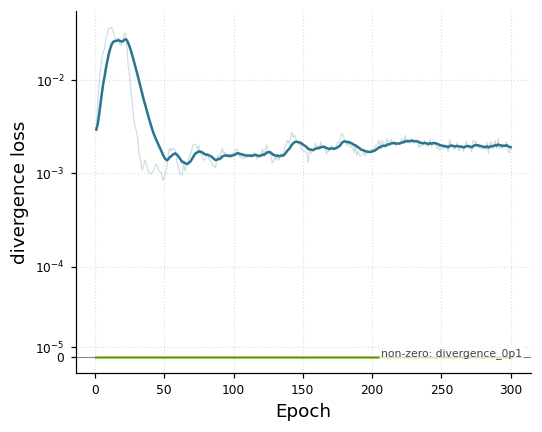

saved: /home/user/Documents/velot/notebooks/supplementary/results_velot_publication_v3/figures/ablation_smoothing_convergence_legend.png.{pdf,png}
Saved ablation_smoothing_convergence_legend.png


In [80]:
if len(loss_df):
    preferred = ["total", "regression", "smoothness", "curl", "divergence", "div"]
    present = list(loss_df["component"].unique())
    components = [c for c in preferred if c in present] + sorted([c for c in present if c not in preferred])

    names = sorted(loss_df["name"].unique())
    cmap = plt.cm.viridis(np.linspace(0.06, 0.88, len(names)))
    name_colour = dict(zip(names, cmap))

    labels_list = [chr(ord("a") + i) for i in range(len(components))]

    for label, comp in zip(labels_list, components):
        fig, ax = plt.subplots(figsize=(5,4))
        subc = loss_df[loss_df["component"].eq(comp)].copy()
        yscale, linthresh = choose_loss_scale(subc["loss"].values)

        for nm, g in subc.groupby("name"):
            g = g.sort_values("epoch")
            y = g["loss"].values.astype(float)
            ax.plot(g["epoch"], y, color=name_colour[nm], alpha=0.25, lw=0.75)
            ax.plot(g["epoch"], ema(y), color=name_colour[nm], lw=1.65)

        if yscale == "log":
            ax.set_yscale("log")
        elif yscale == "symlog":
            ax.set_yscale("symlog", linthresh=linthresh, linscale=0.8)
            ax.axhline(0, color="0.35", lw=0.6, alpha=0.8)
        else:
            vals = subc["loss"].values
            if len(vals) and np.nanmax(np.abs(vals)) == 0:
                ax.set_ylim(-0.05, 0.05)
                ax.text(
                    0.5, 0.5, "all recorded values = 0",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=8, color="0.35",
                    bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.8),
                )

        if comp in {"divergence", "div", "curl"}:
            nonzero_by_name = (
                subc.groupby("name")["loss"]
                    .apply(lambda x: int(np.sum(np.asarray(x) > 0)))
                    .to_dict()
            )
            active = [k for k, v in nonzero_by_name.items() if v > 0]
            if active:
                ax.text(
                    0.98, 0.04,
                    "non-zero: " + ", ".join(active[:3]) + ("…" if len(active) > 3 else ""),
                    transform=ax.transAxes, ha="right", va="bottom",
                    fontsize=7, color="0.25",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
                )

        ax.set_xlabel("Epoch", fontsize=12)
        ax.set_ylabel(f"{comp} loss", fontsize=12)
        ax.grid(ls=":", alpha=0.4)
        plt.tight_layout()
        savefig(fig, f"ablation_smoothing_convergence_{label}")
        plt.show()

    # ---------- standalone vertical legend ----------
    fig_leg = plt.figure(figsize=(0.1, 0.1))
    handles = [plt.Line2D([0], [0], color=name_colour[nm], lw=1.65, label=nm)
               for nm in names]
    leg = fig_leg.legend(handles=handles, loc="center",
                         fontsize=8, frameon=False, ncol=1,
                         title="Ablation", title_fontsize=9)
    fig_leg.canvas.draw()
    bbox = leg.get_window_extent().transformed(fig_leg.dpi_scale_trans.inverted())
    savefig(fig_leg, "ablation_smoothing_convergence_legend.png")
    plt.close(fig_leg)
    print("Saved ablation_smoothing_convergence_legend.png")

else:
    print("No per-loss history was recorded by smooth_velocity in this run.")

## 10. Outputs

| File | Content |
|------|---------|
| `tables/nb2_v3_raw.csv`               | one row per `(ablation × seed)` |
| `tables/nb2_v3_summary.csv`           | mean ± SD per ablation, family-grouped |
| `tables/nb2_v3_paired_tests.csv`      | paired Wilcoxon vs baseline, BH-corrected |
| `tables/nb2_v3_loss_curves.csv`       | per-epoch losses from smoothing |
| `figures/nb2_v3_pareto_and_family.{pdf,png}` | Pareto + family violins (Fig. 1) |
| `figures/nb2_v3_family_bars.{pdf,png}`        | 4-panel family bar charts (Fig. 2) |
| `figures/nb2_v3_metric_heatmap.{pdf,png}`     | normalised heatmap with raw annotations (Fig. 3) |
| `figures/nb2_v3_paired_tests_panel.{pdf,png}` | distributions + significance (Fig. 4) |
| `figures/nb2_v3_field_gallery.{pdf,png}`      | streamline gallery (Fig. 5) |
| `figures/nb2_v3_loss_curves.{pdf,png}`        | training convergence per loss (Fig. 6) |

## 11. Take-aways

* **Disabling the MLP** (`raw_OT_no_MLP`) recovers the OT-only field. Quality drops
  noticeably but is still useful; the speed benefit is large.
* **`lambda_knn = 0`** is the largest quality-killing ablation in the OT-cost family,
  matching the intuition that the kNN penalty is what prevents short-circuit transport.
* **Pseudotime conditioning** matters: removing it (`no_pt_conditioning`) typically
  costs both CBDir and ICCoh. The smoothing network learns more than the regression
  target alone.
* **Epoch budget** plateaus above ~300; `epochs_600` is not worth the extra time.
* **Hidden-dim and `k_smooth`** sit on the flatter part of the response surface — easy
  parameters to tune.
The v3 exact paired-test table uses exact sign-flip permutation p-values matched by seed; do not interpret `ns` as evidence of no effect when `REPEATS` is small.
